# Salary prediction - GROUP 4
Veuillet Gaëtan

## 0. Setup

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor

pd.options.mode.chained_assignment = None

data = pd.read_csv('swiss_job_offers.csv')
print("SHAPE: ", data.shape, "\n")
print(data.dtypes)
data.head()

SHAPE:  (500, 15) 

Diploma                 object
MinYearsExperience      object
Role                    object
Contract                object
Industry                object
CitySize                object
Canton                  object
Perks                   object
CompanySize             object
Languages               object
Holidays                 int64
MaternityLeaveWeeks    float64
PaternityLeaveWeeks    float64
WorkloadPercent          int64
SalaryCHF                int64
dtype: object


,Diploma,MinYearsExperience,Role,Contract,Industry,CitySize,Canton,Perks,CompanySize,Languages,Holidays,MaternityLeaveWeeks,PaternityLeaveWeeks,WorkloadPercent,SalaryCHF
0,PhD,7 to 20,Manager,Permanent,Education,Large city,ZH,Car,Small (50-200),"English, German",25,14.0,2.0,100,314500
1,Bachelor,4 to 10,Senior,Permanent,Manufacturing,Medium city,SO,"Stock options, Meal vouchers",Large (1000+),"French, German",25,16.0,3.0,100,143600
2,Bachelor,2 to 6,Mid-level,Permanent,Manufacturing,Medium city,SO,"Stock options, Car",Medium (200-1000),"English, German",25,14.0,3.0,100,84300
3,Bachelor,0 to 2,Junior,1 year,Healthcare,Small town,BE,AG (train pass),Small (50-200),"English, German",25,14.0,3.0,90,45300
4,PhD,2 to 6,Mid-level,Permanent,Finance,Medium city,FR,Stock options,Medium (200-1000),"French, German",26,16.0,6.0,90,130200


In [73]:
for col in data.columns:
    print(data[col].value_counts())

Diploma
Master            208
Bachelor          191
PhD                61
Apprenticeship     40
Name: count, dtype: int64
MinYearsExperience
2 to 6      172
0 to 2      134
4 to 10      94
0 to 0       46
7 to 20      26
6 to 15      26
10 to 30      2
Name: count, dtype: int64
Role
Mid-level    172
Junior       134
Senior        94
Intern        46
Manager       26
Lead          26
Director       2
Name: count, dtype: int64
Contract
Permanent    289
2 years      123
1 year        65
6 months      23
Name: count, dtype: int64
Industry
Manufacturing    82
IT               54
Education        52
Healthcare       47
Consulting       42
Energy           40
Public Sector    35
Finance          32
Pharma           32
Retail           30
Hospitality      28
Construction     26
Name: count, dtype: int64
CitySize
Medium city    205
Large city     152
Small town     143
Name: count, dtype: int64
Canton
ZH    103
BE     66
AG     39
VD     37
SG     29
LU     26
GE     24
TI     21
VS     20
SO  

# 1. Explore data


## 1.1 The target -> SalaryCHF

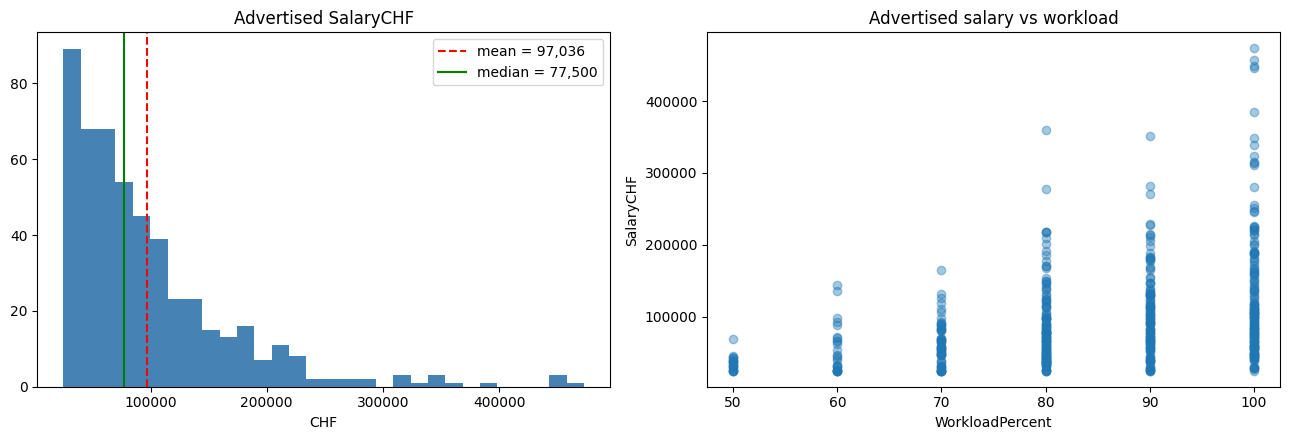

count       500.0
mean      97036.0
std       71692.0
min       25000.0
25%       46875.0
50%       77500.0
75%      121600.0
max      473200.0


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(data["SalaryCHF"], bins=30, color="steelblue")
axes[0].axvline(data["SalaryCHF"].mean(), color="red", linestyle="--",
                label=f"mean = {data['SalaryCHF'].mean():,.0f}")
axes[0].axvline(data["SalaryCHF"].median(), color="green",
                label=f"median = {data['SalaryCHF'].median():,.0f}")
axes[0].set_title("Advertised SalaryCHF")
axes[0].set_xlabel("CHF"); axes[0].legend()

axes[1].scatter(data["WorkloadPercent"], data["SalaryCHF"], alpha=0.4)
axes[1].set_title(f"Advertised salary vs workload")
axes[1].set_xlabel("WorkloadPercent"); axes[1].set_ylabel("SalaryCHF")

plt.tight_layout(); plt.show()

print(data["SalaryCHF"].describe().round(0).to_string())

1 - Distribution is asymmetric. Mean sits well above the median + the right tail stretches to salaries larger that the typical offer. 
-> Comparisons are made on medians (because means would be move around on their own by large salaries)
2 - Part of the salary might be just a workload pourcentage effect -> equivalent made (every job at 100%)




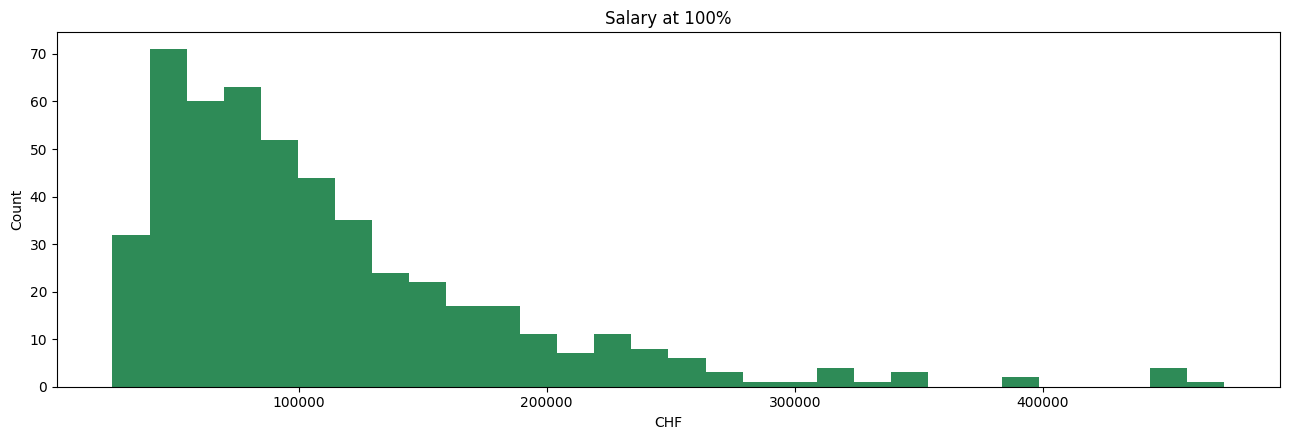

mean   :   111,918 CHF
median :    91,711 CHF
max    :   473,200 CHF  =  5.2 x the median


In [75]:
salary = data["SalaryCHF"] / data["WorkloadPercent"] * 100

fig, axes = plt.subplots(1, 1, figsize=(13, 4.5))

axes.hist(salary, bins=30, color="seagreen")
axes.set_title("Salary at 100%")
axes.set_xlabel("CHF")
axes.set_ylabel("Count")

plt.tight_layout(); plt.show()

print(f"mean   : {salary.mean():>9,.0f} CHF")
print(f"median : {salary.median():>9,.0f} CHF")
print(f"max    : {salary.max():>9,.0f} CHF  =  {salary.max() / salary.median():.1f} x the median")

In [76]:

part_time = data[data["WorkloadPercent"] < 100]
part_time["Role"].value_counts()

data.loc[data["WorkloadPercent"] == 50, "Role"].value_counts()

pd.crosstab(data["WorkloadPercent"], data["Role"])

Role,Director,Intern,Junior,Lead,Manager,Mid-level,Senior
WorkloadPercent,,,,,,,
50,0,4,17,0,0,0,0
60,0,6,12,2,0,4,3
70,0,8,23,0,0,16,13
80,0,9,36,6,5,45,28
90,0,9,18,11,4,52,20
100,2,10,28,7,17,55,30


Still an asymmetry... it's a problem for a linear model, which assumes errors of a comparable size everywhere-> an error of 10k CHF on a 40k interniship salary is not the same mistake as on a 400k CHF director job.

## 1.2 Missing values

How much is missing ? Is the missingness informative ?
If offer with a missing value have clearly a different salary -> column could not be dropped.

,nbr_missing,percent_missing,nbr_unique
Perks,163,32.6,25
Languages,38,7.6,12
MaternityLeaveWeeks,159,31.8,6
PaternityLeaveWeeks,159,31.8,6


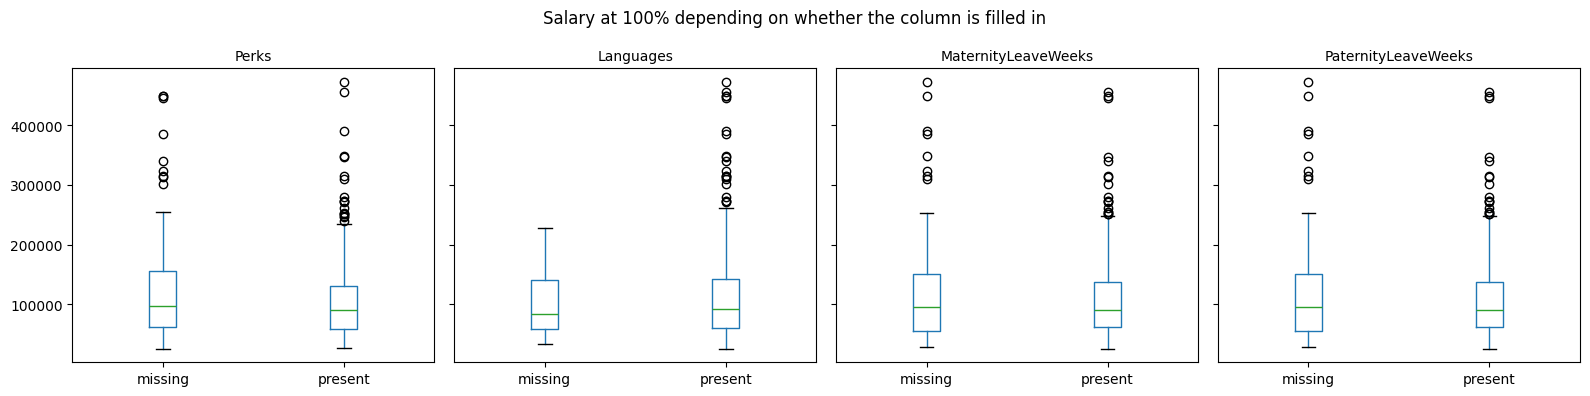

Perks                  median missing =   97,143 | present =   90,143 | gap = +8%
Languages              median missing =   84,325 | present =   92,278 | gap = -9%
MaternityLeaveWeeks    median missing =   95,100 | present =   90,500 | gap = +5%
PaternityLeaveWeeks    median missing =   95,100 | present =   90,500 | gap = +5%


In [77]:
missing = pd.DataFrame({
    "nbr_missing": data.isna().sum(),
    "percent_missing": (data.isna().mean() * 100).round(1),
    "nbr_unique": data.nunique(),
    })
incomplete = missing[missing["nbr_missing"] > 0]
display(incomplete)

fig, axes = plt.subplots(1, len(incomplete), figsize=(4 * len(incomplete), 4), sharey=True)
for ax, col in zip(axes, incomplete.index):
    group = np.where(data[col].isna(), "missing", "present")
    pd.DataFrame({"salary": salary, "group": group}).boxplot(
        column="salary", by="group", ax=ax, grid=False)
    ax.set_title(col, fontsize=10); ax.set_xlabel("")
fig.suptitle("Salary at 100% depending on whether the column is filled in")
plt.tight_layout(); plt.show()

for col in incomplete.index:
    #m is a boolean mask for missing values in the column, ~m is the inverse mask for present values
    m = data[col].isna()
    gap = salary[m].median() / salary[~m].median() - 1
    print(f"{col:22s} median missing = {salary[m].median():>8,.0f} | "
          f"present = {salary[~m].median():>8,.0f} | gap = {gap:+.0%}")

    

The boxes seems to overlap almost entirely. Gaps between medians are under 10% -> nothing suggests Perks or parental leave are paying differently. Can be dropped without losing much information.

An offer that lists no language is a real case in the app so the missing value becomes an explicit "unkwown" cat.

## 1.3 Two columns saying the same thing

MinYYearsExperience and Role seems to have exactly the same number per category (Setup : 0)

In [78]:
display(pd.crosstab(data["Role"], data["MinYearsExperience"]))

MinYearsExperience,0 to 0,0 to 2,10 to 30,2 to 6,4 to 10,6 to 15,7 to 20
Role,,,,,,,
Director,0,0,2,0,0,0,0
Intern,46,0,0,0,0,0,0
Junior,0,134,0,0,0,0,0
Lead,0,0,0,0,0,26,0
Manager,0,0,0,0,0,0,26
Mid-level,0,0,0,172,0,0,0
Senior,0,0,0,0,94,0,0


Every role maps to exactly one experience range. Keeping both -> same info twice -> Role is kept (better usage for the app)

# 2 - Preprocess

In [79]:

data = data.drop('MaternityLeaveWeeks', axis=1)
data = data.drop('PaternityLeaveWeeks', axis=1)
data = data.drop('CitySize', axis=1)
data = data.drop('Perks', axis=1)
data = data.drop('MinYearsExperience', axis=1)
data['Languages'] = data['Languages'].fillna('unknown')


print("Columns kept :", list(data.columns))
data.head()

Columns kept : ['Diploma', 'Role', 'Contract', 'Industry', 'Canton', 'CompanySize', 'Languages', 'Holidays', 'WorkloadPercent', 'SalaryCHF']


,Diploma,Role,Contract,Industry,Canton,CompanySize,Languages,Holidays,WorkloadPercent,SalaryCHF
0,PhD,Manager,Permanent,Education,ZH,Small (50-200),"English, German",25,100,314500
1,Bachelor,Senior,Permanent,Manufacturing,SO,Large (1000+),"French, German",25,100,143600
2,Bachelor,Mid-level,Permanent,Manufacturing,SO,Medium (200-1000),"English, German",25,100,84300
3,Bachelor,Junior,1 year,Healthcare,BE,Small (50-200),"English, German",25,90,45300
4,PhD,Mid-level,Permanent,Finance,FR,Medium (200-1000),"French, German",26,90,130200


## 2.1 Rescaling salary + languages separation

In [80]:
#PUT ALL THE SALARY AT A 100% WORKLOAD
data["SalaryCHF"] = (data["SalaryCHF"] / data["WorkloadPercent"] * 100).round()

data = data.drop('WorkloadPercent', axis=1)

In [81]:
LANGUAGES = ["French", "German", "English", "Italian"]
for lang in LANGUAGES:
    data[f"Lang_{lang}"] = data["Languages"].str.contains(lang).astype(int)
data["LangCount"] = data[[f"Lang_{l}" for l in LANGUAGES]].sum(axis=1)
data = data.drop(columns="Languages")

## 2.2 Shape of relationship

For each column, the categories are sorted by median salary and the title shows the mean sequential ratio (average factor between one category median and the next)

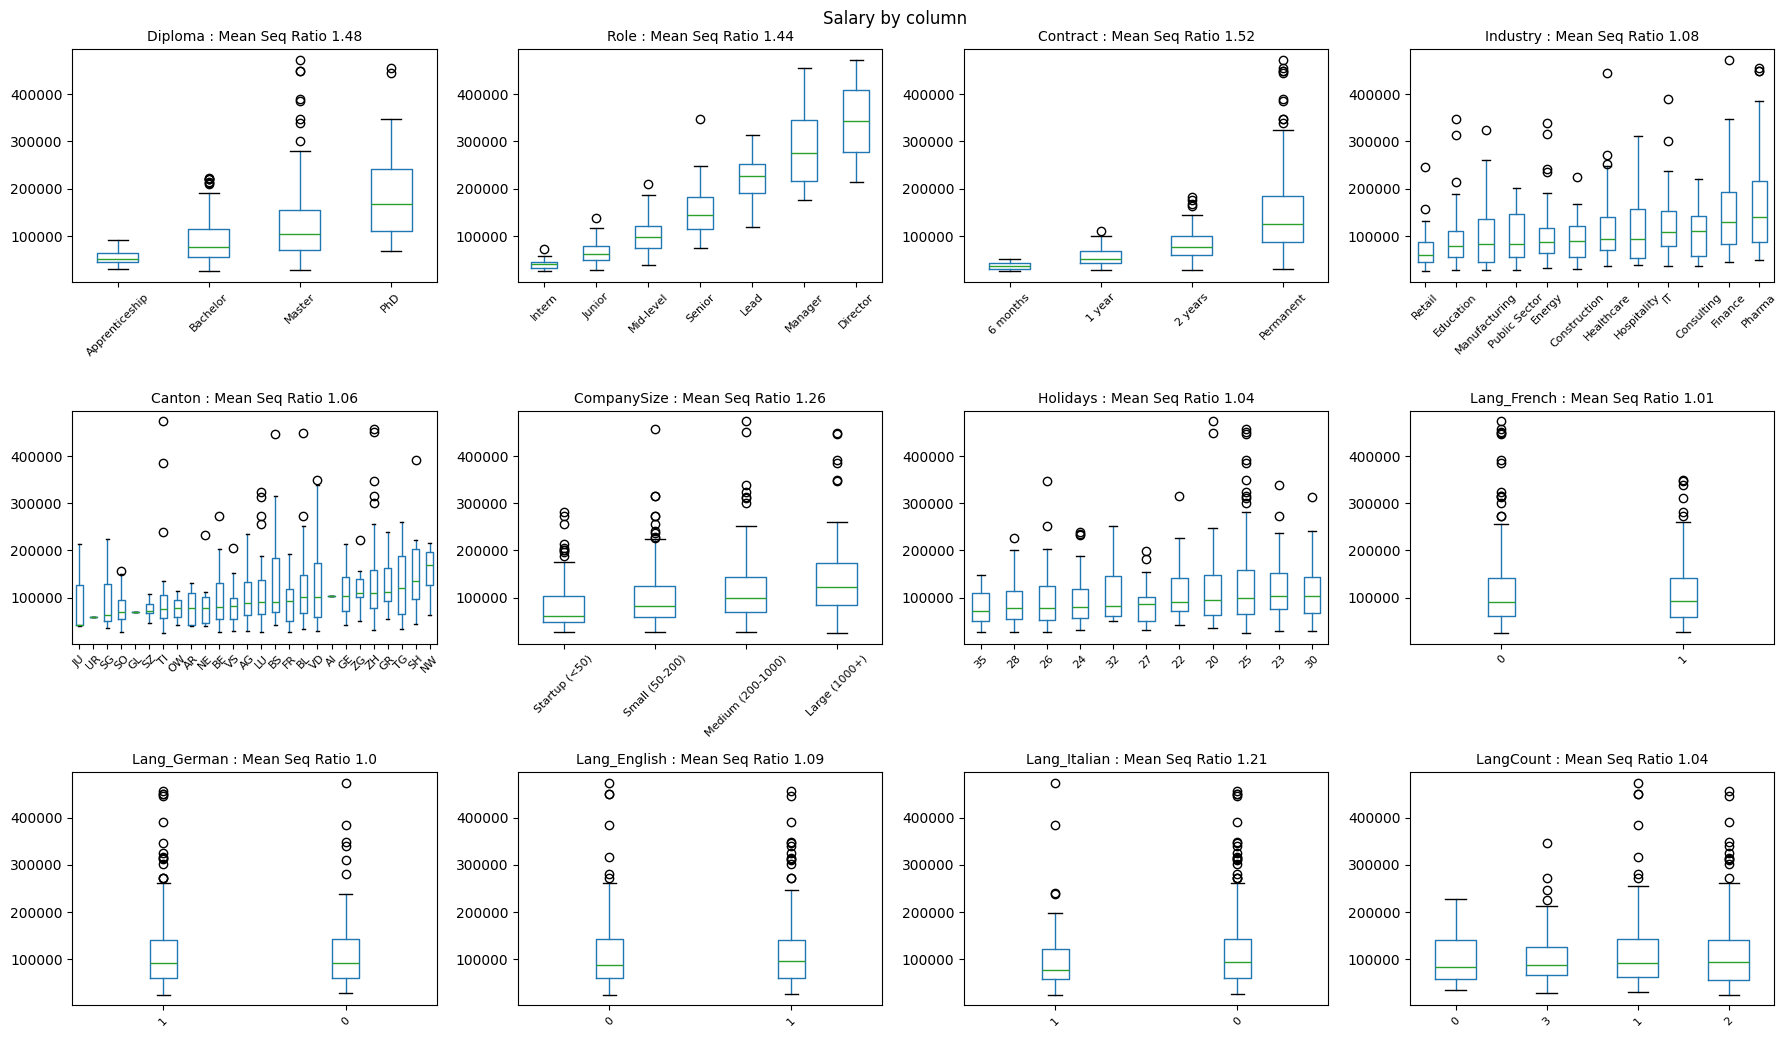

{'Diploma': np.float64(1.48), 'Role': np.float64(1.44), 'Contract': np.float64(1.52)}


In [82]:

col_ratios = {}

cols = data.columns.drop("SalaryCHF")
fig, axes = plt.subplots(4, 4, figsize=(18, 14))

for ax, col in zip(axes.ravel(), cols):
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    order = sorted_medians.index

    sequential_ratio = sorted_medians / sorted_medians.shift(1)

    mean_sequential_ratio = sequential_ratio.mean()

    #print(f"Sequential ratio for {col}: {sequential_ratio}")
    #print(f"-Mean sequential ratio : {mean_sequential_ratio}-")
    
    
    tmp = data.assign(**{col: pd.Categorical(data[col], order, ordered=True)})
    tmp.boxplot(column="SalaryCHF", by=col, ax=ax, grid=False)
    ax.set_title(f"{col} : Mean Seq Ratio {mean_sequential_ratio.round(2)}", fontsize=10)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45, labelsize=8)
    

for ax in axes.ravel()[len(cols):]:
    ax.set_visible(False)

fig.suptitle("Salary by column")
plt.tight_layout()
plt.show()
#ax.set_title('Salary Distribution')

THRESHOLD_RATIO = 1.4

for col in cols:
    sorted_medians = data.groupby(col)["SalaryCHF"].median().sort_values()
    sequential_ratio = sorted_medians / sorted_medians.shift(1)
    mean_sequential_ratio = sequential_ratio.mean()

    if mean_sequential_ratio > THRESHOLD_RATIO:
        col_ratios[col] = mean_sequential_ratio.round(2)

print(col_ratios)



Diploma, Role, Contract grow by a roughly constant factor.

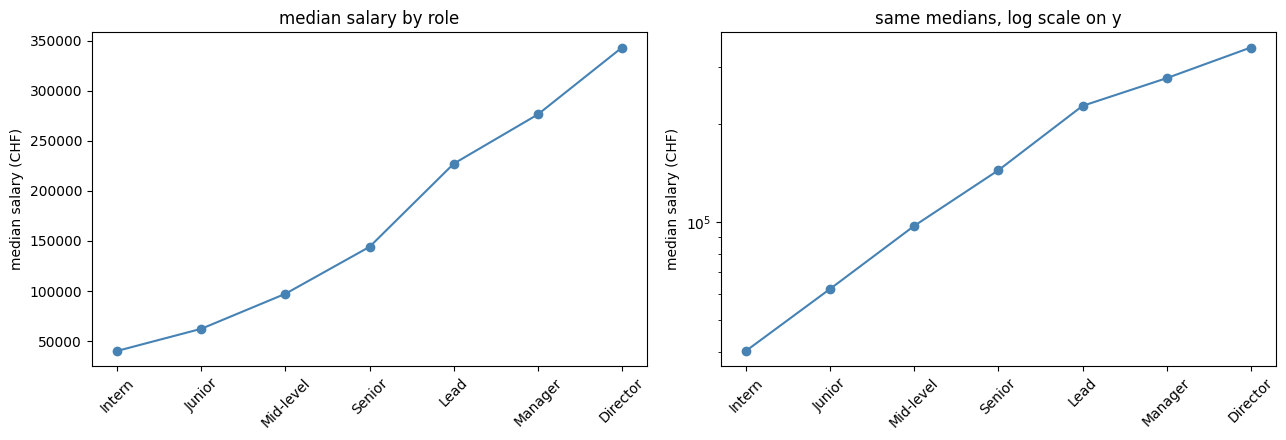

             median  ratio vs previous
Role                                  
Intern      40188.0                NaN
Junior      62300.0               1.55
Mid-level   97272.0               1.56
Senior     144134.0               1.48
Lead       227139.0               1.58
Manager    276338.0               1.22
Director   343150.0               1.24


In [83]:
full_time_salary = data["SalaryCHF"] 
role_median = full_time_salary.groupby(data["Role"]).median().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, log in zip(axes, [False, True]):
    ax.plot(range(len(role_median)), role_median.values, "o-", color="steelblue")
    ax.set_xticks(range(len(role_median)))
    ax.set_xticklabels(role_median.index, rotation=45)
    ax.set_ylabel("median salary (CHF)")
    if log:
        ax.set_yscale("log")
        ax.set_title("same medians, log scale on y")
    else:
        ax.set_title("median salary by role")
plt.tight_layout(); plt.show()

print(pd.DataFrame({"median": role_median.round(0),
                    "ratio vs previous": (role_median / role_median.shift(1)).round(2)}).to_string())

Each step up the ladder multiplies the salary by roughly 1.5 -> doesnt add a fixed amount. Left curve bends upwards -> with a log y-axis, the yame points line up almost staight (flatten at top because manager has 26 offers and director only 2)
Linear regression add fixed amounts -> one coeff by feature, so it can't express "a senior earns 50% more than a mid-level". 

$$\text{salary} = a_0 + a_1x_1 + a_2x_2 + \dots$$

$$\log(\text{salary}) = b_0 + b_1x_1 + b_2x_2 + \dots$$

Taking the exponential of the second line brings it back to CHF:

$$\text{salary} = e^{\,b_0 + b_1x_1 + b_2x_2} = e^{b_0} \times e^{b_1x_1} \times e^{b_2x_2}$$


In [84]:
DIPLOMA_ORDER = ["None", "Apprenticeship", "Bachelor", "Master", "PhD"]
SIZE_ORDER = ["Startup (<50)", "Small (50-200)", "Medium (200-1000)", "Large (1000+)"]

print("Diploma :", sorted(data["Diploma"].unique()))
print("Size :", sorted(data["CompanySize"].unique()))
 
data["DiplomaLevel"] = data["Diploma"].map(
    {name: i for i, name in enumerate(DIPLOMA_ORDER)}
)
data["CompanySizeLevel"] = data["CompanySize"].map(
    {name: i for i, name in enumerate(SIZE_ORDER)}
)
data = data.drop(columns=["Diploma", "CompanySize"])
data

Diploma : ['Apprenticeship', 'Bachelor', 'Master', 'PhD']
Size : ['Large (1000+)', 'Medium (200-1000)', 'Small (50-200)', 'Startup (<50)']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


In [85]:
counts = data["Canton"].value_counts()
rare = counts[counts < 10].index
print(f"{len(rare)} cCANTONS PUT TOGETHER, THEY ARE TOO RARE", list(rare))
data["Canton"] = data["Canton"].where(~data["Canton"].isin(rare), "Other")
data

12 cCANTONS PUT TOGETHER, THEY ARE TOO RARE ['SZ', 'NE', 'ZG', 'GR', 'SH', 'AR', 'NW', 'JU', 'OW', 'UR', 'AI', 'GL']


,Role,Contract,Industry,Canton,Holidays,SalaryCHF,Lang_French,Lang_German,Lang_English,Lang_Italian,LangCount,DiplomaLevel,CompanySizeLevel
0,Manager,Permanent,Education,ZH,25,314500.0,0,1,1,0,2,4,1
1,Senior,Permanent,Manufacturing,SO,25,143600.0,1,1,0,0,2,2,3
2,Mid-level,Permanent,Manufacturing,SO,25,84300.0,0,1,1,0,2,2,2
3,Junior,1 year,Healthcare,BE,25,50333.0,0,1,1,0,2,2,1
4,Mid-level,Permanent,Finance,FR,26,144667.0,1,1,0,0,2,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,Intern,6 months,Hospitality,SO,28,41667.0,1,1,1,0,3,3,0
496,Junior,Permanent,Finance,ZH,25,84500.0,1,1,0,0,2,1,2
497,Senior,Permanent,Manufacturing,TG,24,152750.0,0,1,0,0,1,2,3
498,Mid-level,2 years,Consulting,ZH,28,114444.0,0,1,0,0,1,2,2


# 3. Model training
## 3.1 Splitting the data + model
The dataset is cut into three parts: 
- 300 for train
- 100 for validation
- 100 for test

Why 3 parts ? A model that has seen an offer can repeat its salary without having learned anything. Performance has to be measured on data it has never seen (validation). Validation is then used to choose between the models and to tune the hyperparameters. The test set is untouched until the very end.

Models :
- Linear regression : preficts a weighted sum of the features (additive construciton->add fixed amounts)
- Linear regression + log : log target. Coefficients become multiplicator. 
- Gradient boosting : Build small decision trees in sequence -> each one trained on the residual errors left, and sums them.
- Lasso on the log : Linear model on the log + a penalty on the size of the coefficients. Pushes weak coeff towards 0 and set some to 0, removing corresponding features.

In [86]:

from sklearn import linear_model
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LassoCV

SEED = 42

y = data["SalaryCHF"]
X = data.drop(columns=["SalaryCHF"])

cat_cols = X.select_dtypes("object").columns.tolist()
num_cols = X.select_dtypes("number").columns.tolist()

#StandardScaler substracts the mean and divides by a standard deviation -> have all the feature at the same scale
#onehotencoder creates a binary column for each category and drops the first one to avoid multicollinearity
preprocess = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)])

linear = TransformedTargetRegressor(
    regressor=LinearRegression()
)

linear_log = TransformedTargetRegressor(
    regressor=LinearRegression(),
    func=np.log,
    inverse_func=np.exp,
)

gradient_boosting = TransformedTargetRegressor(
    regressor=GradientBoostingRegressor(random_state=SEED),
    func=np.log,
    inverse_func=np.exp
)

#CV -> cut the train and find hyperparameters
lasso = TransformedTargetRegressor(
    regressor=LassoCV(max_iter=50000, random_state=SEED),
    func=np.log,
    inverse_func=np.exp,
)

model = Pipeline([
    ("prep", preprocess),
    ("reg", linear),
])

model_log = Pipeline([
    ("prep", preprocess),
    ("reg", linear_log),
])

model_gb = Pipeline([
    ("prep", preprocess),
    ("reg", gradient_boosting),
])

model_lasso = Pipeline([
    ("prep", preprocess),
    ("reg", lasso),
])

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED) #test = 20% of the data -> 100
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=SEED)#val = 25% of the remaining 80% -> 20% of the total data -> 100
#train = 300

#model.fit is used to train the model on the training data 
#model.predict is used to make predictions on the validation data
#model.score is used to evaluate the model on the validation data, return R^2
# R^2 = 1 - (sum of squares of residuals / total sum of squares)
model.fit(X_train, y_train)
y_pred = model.predict(X_val)

model_log.fit(X_train, y_train)
y_pred_log = model_log.predict(X_val)

best_score = -np.inf
best_lr = None
best_depth = None
for lr in [0.05, 0.1, 0.2]:
    for d in [2, 3, 5]:
        model_gb.set_params(reg__regressor__learning_rate=lr,
                            reg__regressor__max_depth=d)
        model_gb.fit(X_train, y_train)
        score = round(model_gb.score(X_val, y_val), 4)
        if score > best_score:
            best_score = score
            best_lr = lr
            best_depth = d
        #print(lr, d, round(model_gb.score(X_val, y_val), 4))

print("best: ",best_lr, best_depth, best_score)

model_gb.set_params(reg__regressor__learning_rate=best_lr,
                    reg__regressor__max_depth=best_depth)
model_gb.fit(X_train, y_train)
y_pred_gb = model_gb.predict(X_val)

model_lasso.fit(X_train, y_train)
y_pred_lasso = model_lasso.predict(X_val)

result = {}
abreviations = ["reg_wo_log", "reg_w_log", "grad_boost", "lasso"]

validation_r2_wo_log = model.score(X_val, y_val)
print("Validation R^2 w/o log:", validation_r2_wo_log)

validation_r2_log = model_log.score(X_val, y_val)
print("Validation R^2 log:", validation_r2_log)

validation_r2_gb = model_gb.score(X_val, y_val)
print("Validation R^2 gb:", validation_r2_gb)

validation_r2_lasso = model_lasso.score(X_val, y_val)
print("Validation R^2 lasso:", validation_r2_lasso)

model_log.fit(X_temp, y_temp)      
y_pred_test = model_log.predict(X_test)
print(f"TEST  LOG R^2 = {r2_score(y_test, y_pred_test):.4f}  MAE = {mean_absolute_error(y_test, y_pred_test):.0f} CHF")


best:  0.2 2 0.9508
Validation R^2 w/o log: 0.89757657467395
Validation R^2 log: 0.9878983360922945
Validation R^2 gb: 0.9507746582583745
Validation R^2 lasso: 0.9880640849911504
TEST  LOG R^2 = 0.9923  MAE = 5545 CHF


## 3.4 Results
The top row compares predictions to reality: closer to the red diagonal, the better. The bottom row shows the errors -> more informative

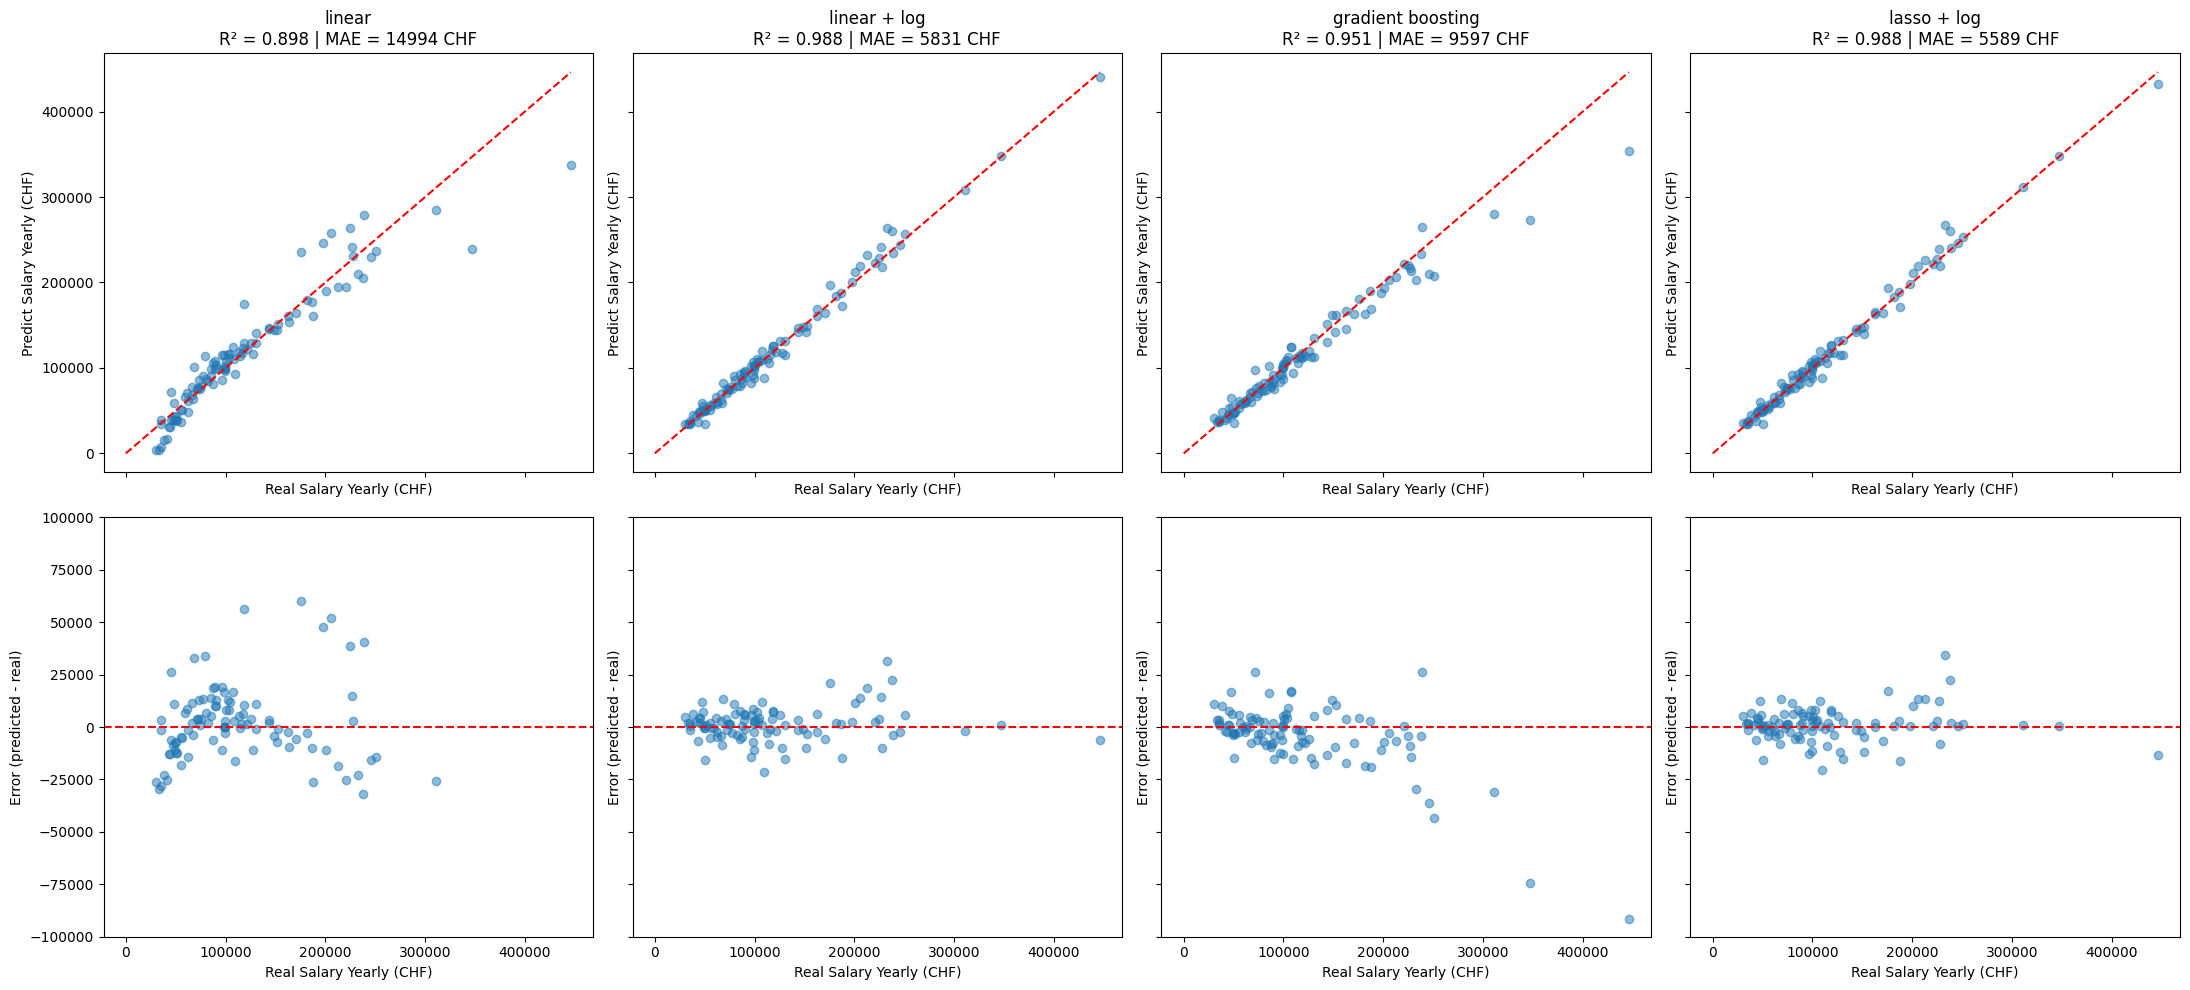

In [87]:
fig, axes = plt.subplots(2, 4, figsize=(22, 10), sharex=True, sharey="row")

preds = [(y_pred, "linear"), (y_pred_log, "linear + log"),
         (y_pred_gb, "gradient boosting"), (y_pred_lasso, "lasso + log")]

for i, (pred, nom) in enumerate(preds):
    ax = axes[0, i]
    ax.scatter(y_val, pred, alpha=0.5)
    lims = [0, max(y_val.max(), pred.max())]
    ax.plot(lims, lims, "r--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Predict Salary Yearly (CHF)")
    ax.set_title(f"{nom}\nR² = {r2_score(y_val, pred):.3f} | MAE = {mean_absolute_error(y_val, pred):.0f} CHF")

    ax = axes[1, i]
    ax.scatter(y_val, pred - y_val, alpha=0.5)
    ax.set_ylim(-100000, 100000)
    ax.axhline(0, color="r", linestyle="--")
    ax.set_xlabel("Real Salary Yearly (CHF)")
    ax.set_ylabel("Error (predicted - real)")
plt.tight_layout()
plt.show()

In [88]:
models = {
    "reg_wo_log": (model, y_pred),
    "reg_w_log": (model_log, y_pred_log),
    "grad_boost": (model_gb, y_pred_gb),
    "lasso": (model_lasso, y_pred_lasso),
}

result = {
    name: {
        "R2_val": r2_score(y_val, pred),
        "MAE_val": mean_absolute_error(y_val, pred),
        "RMSE_val": np.sqrt(mean_squared_error(y_val, pred)),
    }
    for name, (m, pred) in models.items()
}

pd.DataFrame(result).T.round(3)

,R2_val,MAE_val,RMSE_val
reg_wo_log,0.898,14993.529,23550.938
reg_w_log,0.988,5831.381,8095.266
grad_boost,0.951,9597.017,16326.870
lasso,0.988,5589.068,8039.637


The Lasso shoud be selected: same R^2 as the plain log regression, slightly lower MAE, fewer active coefficients.

BUT

### Choosing the model to export

The validation table puts lasso + log and linear + log within noise of each other. Since the
two are equivalent on accuracy, the choice is made on what each one does to the Role column.
the strongest predictor in the dataset, and the field the app asks the user to fill in first. A
model that confuses two roles is unusable in the app even if its average error looks fine.

One-hot reference category (dropped): Role = "Director"
A coefficient of 0 therefore means: predicted exactly like a Director



,linear + log,lasso + log
cat__Role_Intern,-1.978,-1.701
cat__Role_Junior,-1.578,-1.300
cat__Role_Lead,-0.584,-0.306
cat__Role_Manager,-0.272,0.000
cat__Role_Mid-level,-1.226,-0.953
cat__Role_Senior,-0.886,-0.613


,n,real,linear,lasso,linear gap,lasso gap
role,,,,,,
Intern,46,40188.0,37145.0,37588.0,-8%,-6%
Junior,134,62300.0,62016.0,62000.0,-0%,-0%
Mid-level,172,97272.0,97648.0,97817.0,+0%,+1%
Senior,94,144134.0,141743.0,142741.0,-2%,-1%
Lead,26,227139.0,220516.0,220198.0,-3%,-3%
Manager,26,276338.0,268030.0,266684.0,-3%,-3%
Director,2,343150.0,327512.0,257529.0,-5%,-25%


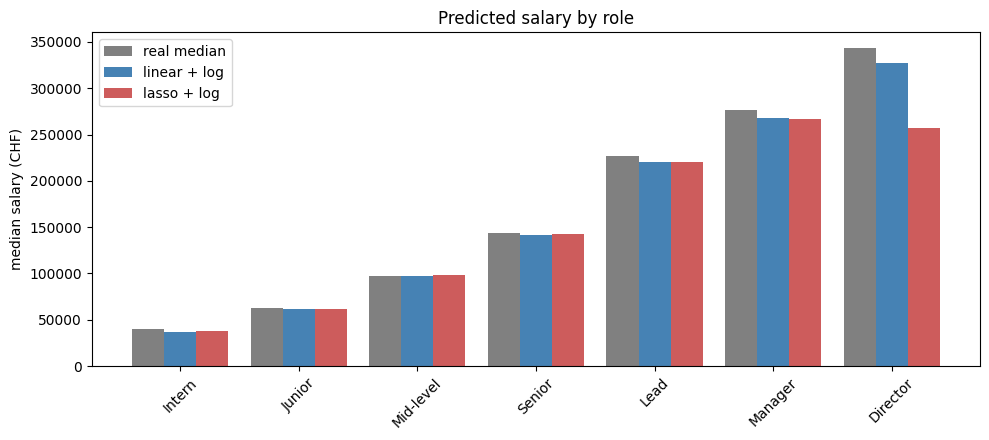

,MAE_CHF,R2_log
linear + log,5545.19,0.97
lasso + log,5354.32,0.97


In [89]:
ROLE_ORDER = ["Intern", "Junior", "Mid-level", "Senior", "Lead", "Manager", "Director"]

model_log.fit(X_temp, y_temp)
model_lasso.fit(X_temp, y_temp)

encoder = model_lasso.named_steps["prep"].named_transformers_["cat"]
reference = encoder.categories_[cat_cols.index("Role")][0]
print(f'One-hot reference category (dropped): Role = "{reference}"')
print(f"A coefficient of 0 therefore means: predicted exactly like a {reference}\n")

features = model_lasso.named_steps["prep"].get_feature_names_out()
coefs = pd.DataFrame({
    "linear + log": model_log.named_steps["reg"].regressor_.coef_,
    "lasso + log":  model_lasso.named_steps["reg"].regressor_.coef_,
}, index=features)
display(coefs[coefs.index.str.startswith("cat__Role_")].round(3))

per_role = pd.DataFrame({
    "role": data["Role"],
    "real": y,
    "linear + log": model_log.predict(X),
    "lasso + log": model_lasso.predict(X),
}).groupby("role").agg(
    n=("real", "size"),
    real=("real", "median"),
    linear=("linear + log", "median"),
    lasso=("lasso + log", "median"),
).reindex(ROLE_ORDER)
per_role["linear gap"] = (per_role["linear"] / per_role["real"] - 1).map("{:+.0%}".format)
per_role["lasso gap"] = (per_role["lasso"] / per_role["real"] - 1).map("{:+.0%}".format)
display(per_role.round(0))

x = np.arange(len(ROLE_ORDER))
width = 0.27
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(x - width, per_role["real"], width, label="real median", color="grey")
ax.bar(x, per_role["linear"], width, label="linear + log", color="steelblue")
ax.bar(x + width, per_role["lasso"], width, label="lasso + log", color="indianred")
ax.set_xticks(x)
ax.set_xticklabels(ROLE_ORDER, rotation=45)
ax.set_ylabel("median salary (CHF)")
ax.set_title("Predicted salary by role")
ax.legend()
plt.tight_layout()
plt.show()

rows = {}
for name, m in [("linear + log", model_log), ("lasso + log", model_lasso)]:
    pred = m.predict(X_test)
    ape = np.abs((pred - y_test) / y_test)
    rows[name] = {
        "MAE_CHF": mean_absolute_error(y_test, pred),
        "R2_log": r2_score(np.log(y_test), np.log(pred)),
    }
display(pd.DataFrame(rows).T.round(2))

The Lasso sets Role_Manager to exactly 0, against -0.272 for the plain regression. Director is
the dropped reference, so a coefficient of 0 does not mean "no effect": it means Manager is
predicted like a Director. The two roles collapse into one level, and with 26 offers against 2,
that level settles near Manager.

Director: real median 343150 -> linear + log gives 327512 (-5%), lasso gives 257529 (-25%).
Manager stays at -3% for both. In the app, someone picking "Director" would get a Manager salary.

The Lasso wins 191 CHF of MAE, about 3% of the error, with the same R2 on the log scale. That
gain is noise, and it does not pay for a broken role.

-> linear + log is exported to the app.

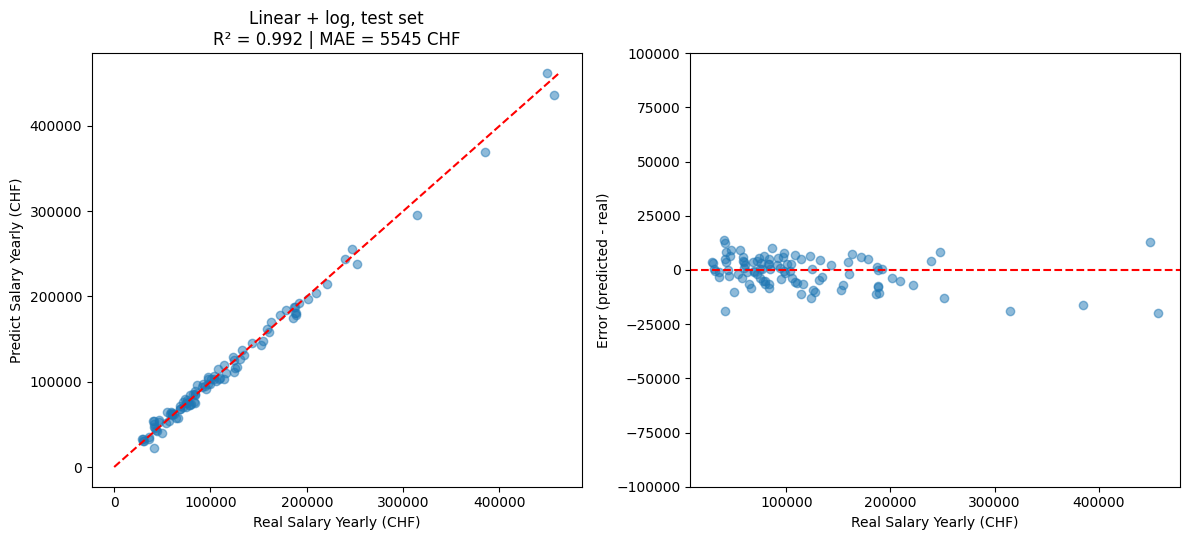

In [90]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

axes[0].scatter(y_test, y_pred_test, alpha=0.5)
lims = [0, max(y_test.max(), y_pred_test.max())]
axes[0].plot(lims, lims, "r--")
axes[0].set_xlabel("Real Salary Yearly (CHF)")
axes[0].set_ylabel("Predict Salary Yearly (CHF)")
axes[0].set_title(f"Linear + log, test set\nR² = {r2_score(y_test, y_pred_test):.3f} | MAE = {mean_absolute_error(y_test, y_pred_test):.0f} CHF")

axes[1].scatter(y_test, y_pred_test - y_test, alpha=0.5)
axes[1].set_ylim(-100000, 100000)
axes[1].axhline(0, color="r", linestyle="--")
axes[1].set_xlabel("Real Salary Yearly (CHF)")
axes[1].set_ylabel("Error (predicted - real)")

plt.tight_layout()
plt.show()

R^2 = 0.992 and MAE = 5545CHF on data never used, close to the validation figures. Residual plot is pretty flat across the range, with a few larger errors on the highest salaries where the training data is thinnest.

## 3.6 Reading the coefficients

The model works on log(salary), a coeff is not a nbr of CHF but a percentage -> a coeff c multiplies the salary by e^c, hence the effect_% column computed as e^C - 1.

In [91]:
r = model_log.named_steps["reg"].regressor_
name = model_log.named_steps["prep"].get_feature_names_out()

coef_log = pd.DataFrame({"feature": name, "coef": r.coef_})
coef_log["effet_%"] = (np.exp(coef_log["coef"]) - 1) * 100
#deleted = coef_log[coef_log["coef"] == 0]

#print(f"alpha kept : {r.alpha_:.6f}")
#print(f"{len(deleted)}/{len(coef_log)} coefficients cancelled")
#print(deleted["feature"].tolist())

coef_log.reindex(coef_log["coef"].abs().sort_values(ascending=False).index).round(2)

,feature,coef,effet_%
8,cat__Role_Intern,-1.98,-86.16
9,cat__Role_Junior,-1.58,-79.36
12,cat__Role_Mid-level,-1.23,-70.66
13,cat__Role_Senior,-0.89,-58.79
10,cat__Role_Lead,-0.58,-44.21
25,cat__Industry_Pharma,0.38,45.75
20,cat__Industry_Finance,0.35,42.35
23,cat__Industry_IT,0.30,34.93
11,cat__Role_Manager,-0.27,-23.84
17,cat__Industry_Consulting,0.26,29.29


Role_intern at -1.70 means an internship pays about 82% LESS than the reference category. 

## 3.7 Export for the app

In [92]:
import json

p = model_log.named_steps["prep"]
r = model_log.named_steps["reg"].regressor_
sc = p.named_transformers_["num"]
enc = p.named_transformers_["cat"]

export = {
    "intercept": float(r.intercept_),
    "numeric": {n: {"mean": float(m), "std": float(s), "coef": float(c)}
                for n, m, s, c in zip(num_cols, sc.mean_, sc.scale_, r.coef_[:len(num_cols)])},
    "categorical": {},
}

i = len(num_cols)
for col, cats in zip(cat_cols, enc.categories_):
    export["categorical"][col] = {"__reference__": cats[0]}
    for c in cats[1:]:
        export["categorical"][col][str(c)] = float(r.coef_[i])
        i += 1

with open("../jobinder/assets/salary_model.json", "w") as f:
    json.dump(export, f, indent=2, ensure_ascii=False)

print(f"{i} export coeff")

42 export coeff


In [93]:
# %% Model tests

from sklearn.metrics import r2_score

failures = []

def check(name, condition, detail=""):
    print(f"{'OK  ' if condition else 'FAIL'} | {name} {detail}")
    if not condition:
        failures.append(name)

def typical_offer():
    """A median offer: median for numeric columns, mode for the others."""
    row = {c: (X[c].median() if X[c].dtype.kind in "if" else X[c].mode()[0])
           for c in X.columns}
    return pd.DataFrame([row])

def predict(**changes):
    o = typical_offer()
    for k, v in changes.items():
        o[k] = v
    return float(model_log.predict(o)[0])


# prediction sanity
p = predict()
check("prediction is strictly positive", p > 0, f"-> {p:,.0f} CHF")
check("prediction is in a plausible range", 20_000 < p < 600_000, f"-> {p:,.0f} CHF")

roles = ["Intern", "Junior", "Mid-level", "Senior", "Lead", "Manager", "Director"]
v = [predict(Role=r) for r in roles]
check("salary increases with seniority", all(a <= b for a, b in zip(v, v[1:])),
      "-> " + " <= ".join(f"{x/1000:.0f}k" for x in v))

d = [predict(DiplomaLevel=i) for i in range(5)]
check("salary increases with diploma level", all(a <= b for a, b in zip(d, d[1:])),
      "-> " + " <= ".join(f"{x/1000:.0f}k" for x in d))


# robustness
check("an unknown canton does not crash", predict(Canton="ZZ") > 0)
check("an unknown role does not crash", predict(Role="Astronaut") > 0)


# split integrity
check("no row shared between train+val and test",
      len(set(X_temp.index) & set(X_test.index)) == 0)
check("the three blocks cover the whole dataset",
      len(X_train) + len(X_val) + len(X_test) == len(X))


# export fidelity
def predict_manual(row):
    z = export["intercept"]
    for n, spec in export["numeric"].items():
        z += (row[n] - spec["mean"]) / spec["std"] * spec["coef"]
    for c, spec in export["categorical"].items():
        z += spec.get(str(row[c]), 0.0) if str(row[c]) != spec["__reference__"] else 0.0
    return np.exp(z)

gap = np.abs(model_log.predict(X) - X.apply(predict_manual, axis=1)).max()
check("the exported JSON reproduces sklearn", gap < 1e-6, f"-> max gap {gap:.1e} CHF")


# performance
r2 = r2_score(y_test, model_log.predict(X_test))
check("R2 on the test set is above 0.90", r2 > 0.90, f"-> {r2:.4f}")


print()
print(f"{len(failures)} test(s) failed" if failures else "All tests passed.")

OK   | prediction is strictly positive -> 124,615 CHF
OK   | prediction is in a plausible range -> 124,615 CHF
OK   | salary increases with seniority -> 59k <= 88k <= 125k <= 175k <= 237k <= 324k <= 425k
OK   | salary increases with diploma level -> 79k <= 92k <= 107k <= 125k <= 145k
OK   | an unknown canton does not crash 
OK   | an unknown role does not crash 
OK   | no row shared between train+val and test 
OK   | the three blocks cover the whole dataset 
OK   | the exported JSON reproduces sklearn -> max gap 8.1e-10 CHF
OK   | R2 on the test set is above 0.90 -> 0.9923

All tests passed.


c:\Users\gaeta\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
c:\Users\gaeta\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
